# Post-Processing Ablation Study — OF_full_run_v2

This notebook evaluates the impact of **7 post-processing methods** on the
Onsets & Frames baseline model (OF_full_run_v2, 1000 epochs, full MAESTRO).

## Experimental Design

**Phase 1 — Individual isolation tests (one method at a time):**
- Exp 0: Baseline (no post-processing)
- Exp 1: Method 3 only — Minimum Note Duration
- Exp 2: Method 1 only — Onset-Conditioned Offset
- Exp 3: Method 2 only — Frame-Level Smoothing
- Exp 4: Method 4 only — Duplicate Removal
- Exp 5: Method 5 only — Chord-Aware Onset Grouping
- Exp 6: Method 6 only — Adaptive Thresholding
- Exp 7: Method 7 only — Sustain Pedal Extension

**Phase 2 — Incremental combinations (building best pipeline):**
- Exp 8: Methods 1+3 (onset offset + min duration)
- Exp 9: Methods 1+2+3 (add frame smoothing)
- Exp 10: Methods 1+2+3+4+5 (add event-level refinement)
- Exp 11: Best combo from Phase 1 winners

**Phase 3 — Final comparison and selection**

---
## Environment Setup

In [1]:
# ── GPU check ─────────────────────────────────────────────────────────────
import torch
assert torch.cuda.is_available(), "No GPU! Change runtime to GPU."
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"CUDA: {torch.version.cuda}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU : NVIDIA RTX PRO 6000 Blackwell Server Edition
CUDA: 12.8
VRAM: 102.0 GB


In [2]:
# ── Mount Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted ✓")

Mounted at /content/drive
Drive mounted ✓


In [3]:
# ── Clone / update repo ────────────────────────────────────────────────────
import os
from getpass import getpass

REPO_DIR = '/content/AMT_FYP'
TOKEN    = getpass('GitHub token: ')

if not os.path.exists(REPO_DIR):
    os.system(f"git clone https://{TOKEN}@github.com/Mobinmo83/AMT_FYP.git {REPO_DIR}")
    print(f"Cloned → {REPO_DIR}")
else:
    os.system(f"cd {REPO_DIR} && git pull")
    print(f"Pulled latest → {REPO_DIR}")

GitHub token: ··········
Cloned → /content/AMT_FYP


In [4]:
%cd /content/AMT_FYP/piano_amt
!pip install -q -r requirements.txt
print("Packages installed ✓")

/content/AMT_FYP/piano_amt
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 58.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 64.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 160.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 131.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 7.7 MB/s eta 0:00:00
Packages installed ✓


In [5]:
# ── sys.path + imports ─────────────────────────────────────────────────────
import sys
import mir_eval

PROJECT_ROOT = '/content/AMT_FYP/piano_amt'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.constants import N_MELS, FRAMES_PER_SECOND, N_KEYS
assert N_MELS == 229 and abs(FRAMES_PER_SECOND - 31.25) < 1e-6 and N_KEYS == 88

from models.onsets_frames.decode_advanced import advanced_rolls_to_note_events
from models.onsets_frames.evaluate_advanced import run_advanced_evaluation

print("All imports OK ✓")
print("  decode_advanced.py  ✓")
print("  evaluate_advanced.py ✓")

All imports OK ✓
  decode_advanced.py  ✓
  evaluate_advanced.py ✓


---
## Paths & Configuration

In [9]:
import os, glob

# ── Paths ────────────────────────────────────────────────────────────────────
DRIVE_ROOT   = '/content/drive/MyDrive/piano_amt'
MAESTRO_ROOT = f'{DRIVE_ROOT}/maestro-v3.0.0'
CACHE_DIR    = f'{DRIVE_ROOT}/cache'
RUNS_DIR     = f'{DRIVE_ROOT}/runs'
BEST_CKPT    = f'{RUNS_DIR}/OF_full_run_v2/checkpoints/best.pt'

# ── Evaluation settings ──────────────────────────────────────────────────────
SPLIT            = 'validation'     # 'test' for final, 'validation' for tuning
MODEL_COMPLEXITY = 48
MAX_FILES        = None       # None = all files in split

# ── Common kwargs (locked for all experiments) ───────────────────────────────
EVAL_KWARGS = dict(
    checkpoint_path      = BEST_CKPT,
    maestro_root         = MAESTRO_ROOT,
    cache_dir            = CACHE_DIR,
    split                = SPLIT,
    max_files            = MAX_FILES,
    model_complexity     = MODEL_COMPLEXITY,
    save_midi            = False,
    save_plots           = False,
    onset_threshold      = 0.4,
    frame_threshold      = 0.4,
    offset_threshold     = 0.5,
    onset_tolerance      = 0.05,
    offset_ratio         = 0.2,
    offset_min_tolerance = 0.05,
    velocity_tolerance   = 0.1,
)

# ── Storage for all results ──────────────────────────────────────────────────
ALL_SUMMARIES = {}  # config_name → summary dict

# ── Verify ───────────────────────────────────────────────────────────────────
assert os.path.exists(BEST_CKPT), f"Checkpoint not found: {BEST_CKPT}"
npzs = glob.glob(f'{CACHE_DIR}/*.npz')
print(f"Checkpoint : {BEST_CKPT}")
print(f"Cache files: {len(npzs)}")
print(f"Split      : {SPLIT}")
print(f"Max files  : {MAX_FILES or 'ALL'}")
print("\nReady ✓")

Checkpoint : /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
Cache files: 1276
Split      : validation
Max files  : ALL

Ready ✓


---
# Parameter Tuning using validation set

### Exp 0 — Baseline (No Post-Processing)
All methods OFF. Should match your original `eval_test` results exactly.

In [10]:
ALL_SUMMARIES['exp0_baseline'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='exp0_baseline_validation',
)
print("Exp 0 DONE ✓")

Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'exp0_baseline_validation'
    (no post-processing — baseline decode)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 505.3s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexity=48, 26,491

### Exp 1 — Method 3 ONLY: Minimum Note Duration
Increases MIN_DUR from 16ms to 50ms. Removes spurious very short notes.

In [11]:

ALL_SUMMARIES['exp1_m3_min_dur'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='exp1_m3_min_dur_validation',
    min_note_duration_ms=55.0, # 60 before
)
print("Exp 1 DONE ✓")

Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'exp1_m3_min_dur_validation'
    ✓ Min Note Duration = 55.0ms

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 477.0s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexity=48, 26,491,256 par

### Exp 2 — Method 1 ONLY: Onset-Conditioned Offset
Uses the offset head to end notes. The offset head is trained but ignored by original decode.

In [15]:
# not effective after tuning expriemnt with 0.9
ALL_SUMMARIES['exp2_m1_offset'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='exp2_m1_offset_validation',
    use_onset_conditioned_offset=True,
)
print("Exp 2 DONE ✓")

Device: NVIDIA A100-SXM4-80GB
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'exp2_m1_offset_validation'
    ✓ Onset-Conditioned Offset

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 1349.2s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.50
    frame_threshold:   0.50
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexity=48, 26,491,256 params)
  Checkpoint: epoch 

### Exp 3 — Method 2 ONLY: Frame-Level Smoothing
Applies median filter (kernel=7) to frame roll before decoding.

In [12]:
ALL_SUMMARIES['exp3_m2_smooth'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='exp3_m2_smooth_validation',
    use_frame_smoothing=True,
    frame_smoothing_kernel=3,
    frame_smoothing_method='gaussian', # closing, median
)
print("Exp 3 DONE ✓")

Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'exp3_m2_smooth_validation'
    ✓ Frame Smoothing (kernel=3, method=closing)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 1364.9s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexity=48

### Exp 4 — Method 4 ONLY: Velocity-Aware Duplicate Removal
Removes duplicate same-pitch onsets within 50ms, keeps highest velocity.

In [17]:
ALL_SUMMARIES['exp4_m4_dedup'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='exp4_m4_dedup_validation',
    use_duplicate_removal=True,
    duplicate_tolerance_sec=0.06, #2.0.04 before, 1. 0.05 before that
)
print("Exp 4 DONE ✓")

Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'exp4_m4_dedup_validation'
    ✓ Duplicate Removal (tol=65ms)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 499.4s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexity=48, 26,491,256 par

### Exp 5 — Method 5 ONLY: Chord-Aware Onset Grouping
Snaps near-simultaneous onsets (within 30ms) to median time.

In [12]:
# RESUE AS HMM MARKOV MDOEL
ALL_SUMMARIES['exp5_m5_chord'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='exp5_m5_chord_validation',
    use_chord_grouping=True,
    chord_tolerance_sec=0.05,
    chord_snap_to='median',
)
print("Exp 5 DONE ✓")

Device: NVIDIA A100-SXM4-80GB
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'exp5_m5_chord_validation'
    ✓ Chord Grouping (tol=50ms, snap=median)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 1410.1s









        — Post-processing configuration —         

  Config name:  exp5_m5_chord_validation
  Note metrics: advanced decoder
  Frame metric: original frame path

  Method 1  Onset-conditioned offset : OFF
            offset_threshold         : 0.50
  Method 2  Frame smoothing          : OFF
            smoothing_kernel         : 7
            smoothing_method         : median
  Method 3  Min note duration        : 16.0 ms
  Method 4  Duplicate removal        : OFF
            duplicate_tolerance      : 50.0 ms
  Method 5  Chor

### Exp 6 — Method 6 ONLY: Adaptive Thresholding
Per-piece threshold adaptation: threshold = 0.5 + k × std(activations).

In [14]:
ALL_SUMMARIES['exp6_m6_adaptive'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='exp6_m6_adaptive_validation',
    use_adaptive_thresholds=True,
    adaptive_onset_k=0.3, # -0.1 and -2 before
    adaptive_frame_k=0.3, # -0.1 and -2 before
)
print("Exp 6 DONE ✓")

Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'exp6_m6_adaptive_validation'
    ✓ Adaptive Thresholds (onset_k=0.3, frame_k=0.3)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 509.6s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexi

### Exp 7 — Method 7 ONLY: Sustain Pedal Extension
Extends note offsets in regions with high simultaneous activity (likely pedal).

In [16]:
ALL_SUMMARIES['exp7_m7_pedal'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='exp7_m7_pedal_validation',
    use_pedal_extension=True,
    pedal_energy_threshold=5.0,
    pedal_max_extension_sec=1.0,
)
print("Exp 7 DONE ✓")

Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'exp7_m7_pedal_validation'
    ✓ Pedal Extension (threshold=5.0, max=1.0s)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 504.7s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexity=48, 2

---
# Tuning Combination Experiments

Based on Phase 1 results, combine methods that individually showed improvement.

In [ ]:

EVAL_KWARGS = dict(
    checkpoint_path      = BEST_CKPT,
    maestro_root         = MAESTRO_ROOT,
    cache_dir            = CACHE_DIR,
    split                = 'validation',   # on valdiation set for tuning
    max_files            = None,
    model_complexity     = 48,
    save_midi            = False,
    save_plots           = False,

    # Global decode thresholds (TUNED)
    onset_threshold      = 0.4,
    frame_threshold      = 0.4,
    offset_threshold     = 0.5,   # NOT USING IT AS METHOD 1 HASNT BEEN HELPFULL WUTH OFFSET EVAL

    # mir_eval tolerances
    onset_tolerance      = 0.05,
    offset_ratio         = 0.2,
    offset_min_tolerance = 0.05,
    velocity_tolerance   = 0.1,
)


### Exp 8 — Method 2 & Method 3: Frame-Level Smoothing & Minimum Note Duration


In [23]:
# M2+M3 (without M4 and M6)
ALL_SUMMARIES['M2+M3_comb'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='M2+M3_comb_validation',
    use_frame_smoothing     = True,
    frame_smoothing_kernel  = 3,
    frame_smoothing_method  = 'closing',
    min_note_duration_ms    = 55.0,
)


Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'full_comb_validation'
    ✓ Frame Smoothing (kernel=3, method=closing)
    ✓ Min Note Duration = 55.0ms

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 1348.3s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      On

### Exp 9 — Method 2 & Method 4: Frame-Level Smoothing & Velocity-Aware Duplicate Removal


In [22]:
# M2+M4 (without M3 and M6)
ALL_SUMMARIES['M2+M4_comb_'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='M2+M4_comb_validation',
    use_frame_smoothing     = True,
    frame_smoothing_kernel  = 3,
    frame_smoothing_method  = 'closing',
    use_duplicate_removal   = True,
    duplicate_tolerance_sec = 0.06,
)


Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'full_comb_validation'
    ✓ Frame Smoothing (kernel=3, method=closing)
    ✓ Duplicate Removal (tol=60ms)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 1354.9s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      

### Exp 10 — Method 3 & Method 4: Minimum Note Duration & Velocity-Aware Duplicate Removal


In [20]:
# M3+M4 only (the "minimal hero")
ALL_SUMMARIES['M3+M4_comb'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='M3+M4_comb_validation',
    min_note_duration_ms    = 55.0,
    use_duplicate_removal   = True,
    duplicate_tolerance_sec = 0.06,
)




Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'minimal_comb_validation'
    ✓ Min Note Duration = 55.0ms
    ✓ Duplicate Removal (tol=60ms)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 481.2s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrame

### Exp 11 — Method 2 & Method 3 & Method 4: Frame-Level Smoothing & Minimum Note Duration & Velocity-Aware Duplicate Removal


In [21]:
# M2+M3+M4 (without M6)
ALL_SUMMARIES[' M2+M3+M4_comb'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name=' M2+M3+M4_comb_validation',
    use_frame_smoothing     = True,
    frame_smoothing_kernel  = 3,
    frame_smoothing_method  = 'closing',
    min_note_duration_ms    = 55.0,
    use_duplicate_removal   = True,
    duplicate_tolerance_sec = 0.06,
)


Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'full_comb_validation'
    ✓ Frame Smoothing (kernel=3, method=closing)
    ✓ Min Note Duration = 55.0ms
    ✓ Duplicate Removal (tol=60ms)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 1353.7s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0

### Exp 12 — Method 2 & Method 3 & Method 4 & method 6: Frame-Level Smoothing & Minimum Note Duration & Velocity-Aware Duplicate Removal & Adaptive Thresholds


In [19]:


# ── configuration: M2 + M3 + M4 + M6 ON ; M1, M5, M7 OFF ──
ALL_SUMMARIES['all_methods_final'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='all_methods_final_validation',

    # M1 OFF — confirmed bad at 0.2, 0.5, 0.9 across three attempts
    # (do not pass use_onset_conditioned_offset)


    # M2 ON — closing k=3, small positive at 0.4/0.4
    use_frame_smoothing      = True,
    frame_smoothing_kernel   = 3,
    frame_smoothing_method   = 'closing',

    # M3 ON — 55 ms optimal at 0.4/0.4
    min_note_duration_ms     = 55.0,

    # M4 ON — 60 ms optimal.
    use_duplicate_removal    = True,
    duplicate_tolerance_sec  = 0.06,

    # M5 OFF — reserved for separate chord reconstruction (qualitative only)

    # M6 ON — k = +0.3, small positive at 0.4/0.4
    use_adaptive_thresholds  = True,
    adaptive_onset_k         = 0.2,
    adaptive_frame_k         = 0.2,


    # M7 OFF — turned negative at 0.4/0.4 (lower frame_threshold implicitly
)


Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'all_methods_final_validation'
    ✓ Frame Smoothing (kernel=3, method=closing)
    ✓ Min Note Duration = 55.0ms
    ✓ Duplicate Removal (tol=60ms)
    ✓ Adaptive Thresholds (onset_k=0.2, frame_k=0.2)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 1350.6s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUM

##  choosen final post proccesing method tuning

In [31]:

EVAL_KWARGS_val_final = dict(
    checkpoint_path      = BEST_CKPT,
    maestro_root         = MAESTRO_ROOT,
    cache_dir            = CACHE_DIR,
    split                = 'validation',   # on valdiation set for tuning
    max_files            = None,
    model_complexity     = 48,
    save_midi            = False,
    save_plots           = False,

    # Global decode thresholds (TUNED)
    onset_threshold      = 0.4,
    frame_threshold      = 0.4,
    offset_threshold     = 0.5,   # NOT USING IT AS METHOD 1 HASNT BEEN HELPFULL WUTH OFFSET EVAL

    # mir_eval tolerances
    onset_tolerance      = 0.05,
    offset_ratio         = 0.2,
    offset_min_tolerance = 0.05,
    velocity_tolerance   = 0.1,
)


In [32]:
# M2+M3+M4 (without M6)
ALL_SUMMARIES['M2+M3+M4_final_comb'] = run_advanced_evaluation(
    **EVAL_KWARGS_val_final,
    config_name='full_comb_validation',
    use_frame_smoothing     = True,
    frame_smoothing_kernel  = 3,
    frame_smoothing_method  = 'closing',
    min_note_duration_ms    = 55.0,
    use_duplicate_removal   = True,
    duplicate_tolerance_sec = 0.06,
)


Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'full_comb_validation'
    ✓ Frame Smoothing (kernel=2, method=closing)
    ✓ Min Note Duration = 55.0ms
    ✓ Duplicate Removal (tol=60ms)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 1343.1s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0

In [33]:
# M3+M4
ALL_SUMMARIES['M3+M4_final_comb_m6'] = run_advanced_evaluation(
    **EVAL_KWARGS_val_final,
    config_name='M3+M4_final_comb_validation',
    min_note_duration_ms    = 55.0,
    use_duplicate_removal   = True,
    duplicate_tolerance_sec = 0.06,
)


Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'M3+M4_final_comb_validation'
    ✓ Min Note Duration = 55.0ms
    ✓ Duplicate Removal (tol=60ms)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 493.4s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndF

---
# Individual Method Isolation Tests on test set after tuning on validation set

Each experiment enables exactly ONE method to measure its isolated effect.

In [34]:
import os, glob

# ── Paths ────────────────────────────────────────────────────────────────────
DRIVE_ROOT   = '/content/drive/MyDrive/piano_amt'
MAESTRO_ROOT = f'{DRIVE_ROOT}/maestro-v3.0.0'
CACHE_DIR    = f'{DRIVE_ROOT}/cache'
RUNS_DIR     = f'{DRIVE_ROOT}/runs'
BEST_CKPT    = f'{RUNS_DIR}/OF_full_run_v2/checkpoints/best.pt'

# ── Evaluation settings ──────────────────────────────────────────────────────
SPLIT            = 'test'     # 'test' for final, 'validation' for tuning
MODEL_COMPLEXITY = 48
MAX_FILES        = None       # None = all files in split

# ── Common kwargs (locked for all experiments) ───────────────────────────────
EVAL_KWARGS_test = dict(
    checkpoint_path      = BEST_CKPT,
    maestro_root         = MAESTRO_ROOT,
    cache_dir            = CACHE_DIR,
    split                = SPLIT,
    max_files            = MAX_FILES,
    model_complexity     = MODEL_COMPLEXITY,
    save_midi            = True,
    save_plots           = True,
    onset_threshold      = 0.4,
    frame_threshold      = 0.4,
    offset_threshold     = 0.5,
    onset_tolerance      = 0.05,
    offset_ratio         = 0.2,
    offset_min_tolerance = 0.05,
    velocity_tolerance   = 0.1,
)

# ── Storage for all results ──────────────────────────────────────────────────
ALL_SUMMARIES = {}  # config_name → summary dict

# ── Verify ───────────────────────────────────────────────────────────────────
assert os.path.exists(BEST_CKPT), f"Checkpoint not found: {BEST_CKPT}"
npzs = glob.glob(f'{CACHE_DIR}/*.npz')
print(f"Checkpoint : {BEST_CKPT}")
print(f"Cache files: {len(npzs)}")
print(f"Split      : {SPLIT}")
print(f"Max files  : {MAX_FILES or 'ALL'}")
print("\nReady ✓")

Checkpoint : /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
Cache files: 1276
Split      : test
Max files  : ALL

Ready ✓


### Baseline (No Post-Processing)
All methods OFF. Should match your original `eval_test` results exactly.

In [35]:
ALL_SUMMARIES['adv_baseline'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='adv_baseline',
)


Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'adv_baseline'
    (no post-processing — baseline decode)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 499.9s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexity=48, 26,491,256 params)

### Method 2 ONLY: Frame-Level Smoothing
Applies median filter (kernel=7) to frame roll before decoding.

In [37]:
ALL_SUMMARIES['adv_m2_smooth'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='adv_m2_smooth',
    use_frame_smoothing=True,
    frame_smoothing_kernel=3,
    frame_smoothing_method='closing',
)


Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'adv_m2_smooth'
    ✓ Frame Smoothing (kernel=3, method=closing)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 1357.5s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexity=48, 26,491,256

### Method 3 ONLY: Minimum Note Duration (50ms)
Increases MIN_DUR from 16ms to 50ms. Removes spurious very short notes.

In [36]:
ALL_SUMMARIES['adv_m3_min_dur'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='adv_m3_min_dur',
    min_note_duration_ms=55.0,
)


Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'adv_m3_min_dur'
    ✓ Min Note Duration = 55.0ms

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 496.0s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexity=48, 26,491,256 params)
  Check

### Method 4 ONLY: Velocity-Aware Duplicate Removal
Removes duplicate same-pitch onsets within 50ms, keeps highest velocity.

In [38]:
ALL_SUMMARIES['adv_m4_dedup'] = run_advanced_evaluation(
    **EVAL_KWARGS,
    config_name='adv_m4_dedup',
    use_duplicate_removal=True,
    duplicate_tolerance_sec=0.06,
)


Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'adv_m4_dedup'
    ✓ Duplicate Removal (tol=60ms)

Evaluating 137/137 files from 'validation' split...
  Strategy: full-length single-pass inference + advanced post-processing

  Evaluated 137/137 files in 494.3s







        — Decoding + evaluation protocol —        

  Decode thresholds:
    onset_threshold:   0.40
    frame_threshold:   0.40
    offset_threshold:  0.50
  Evaluation tolerances:
    onset_tolerance:   50 ms
    pitch_tolerance:   0.25 (25 cents)
    offset_ratio:      0.2
    offset_min_tol:    50 ms
    velocity_tolerance:0.1
    mir_eval version:  0.8.2





  EVALUATION SUMMARY — validation split (n=137)

  Dataset:    MAESTRO v3.0.0, validation split
  Model:      OnsetsAndFrames (complexity=48, 26,491,256 params)
  Check

---
## Results — Individual Method Comparison

In [39]:
# ── Phase 1 Results Table ────────────────────────────────────────────────────
import pandas as pd

phase1_configs = [
    'adv_baseline', 'adv_m3_min_dur', 'adv_m2_smooth', 'adv_m4_dedup'
]

baseline = ALL_SUMMARIES.get('adv_baseline', {})
base_note  = baseline.get('adv_note_f1', baseline.get('note_f1', 0))
base_noff  = baseline.get('adv_note_with_offset_f1', baseline.get('note_with_offset_f1', 0))
base_noffv = baseline.get('adv_note_with_offset_vel_f1', baseline.get('note_with_offset_vel_f1', 0))

print('\n' + '=' * 95)
print('INDIVIDUAL METHOD ISOLATION RESULTS')
print('=' * 95)
print(f"\nBaseline: Note F1={base_note:.4f}  N+Off F1={base_noff:.4f}  N+O+V F1={base_noffv:.4f}")
print(f"\n{'Config':<22s}  {'Adv Note F1':>11s}  {'Adv N+O F1':>11s}  {'Adv N+O+V':>10s}  {'Δ Note':>7s}  {'Δ N+O':>7s}  {'Δ N+O+V':>8s}  {'Dup Rate':>8s}")
print('-' * 95)

for cfg in phase1_configs:
    s = ALL_SUMMARIES.get(cfg, {})
    if not s:
        continue
    adv_n   = s.get('adv_note_f1', s.get('note_f1', 0))
    adv_no  = s.get('adv_note_with_offset_f1', s.get('note_with_offset_f1', 0))
    adv_nov = s.get('adv_note_with_offset_vel_f1', s.get('note_with_offset_vel_f1', 0))
    dn  = adv_n - base_note
    dno = adv_no - base_noff
    dnov = adv_nov - base_noffv
    dup = s.get('ea_duplicate_note_rate', 0)
    sn  = '+' if dn >= 0 else ''
    sno = '+' if dno >= 0 else ''
    snov = '+' if dnov >= 0 else ''
    print(f"{cfg:<22s}  {adv_n:>11.4f}  {adv_no:>11.4f}  {adv_nov:>10.4f}  {sn}{dn:>6.4f}  {sno}{dno:>6.4f}  {snov}{dnov:>7.4f}  {dup:>8.4f}")

print()


INDIVIDUAL METHOD ISOLATION RESULTS

Baseline: Note F1=0.9347  N+Off F1=0.6192  N+O+V F1=0.5901

Config                  Adv Note F1   Adv N+O F1   Adv N+O+V   Δ Note    Δ N+O   Δ N+O+V  Dup Rate
-----------------------------------------------------------------------------------------------
adv_baseline                 0.9347       0.6192      0.5901  +0.0000  +0.0000  + 0.0000    0.0348
adv_m3_min_dur               0.9499       0.6292      0.5997  +0.0152  +0.0100  + 0.0096    0.0000
adv_m2_smooth                0.9343       0.6256      0.5963  -0.0004  +0.0064  + 0.0062    0.0348
adv_m4_dedup                 0.9507       0.6259      0.5967  +0.0160  +0.0066  + 0.0066    0.0000



---
# Combination Experiments on test set

Based on Phase 1 results, combine methods that individually showed improvement.

###  Methods 3+4: Minimum Note Duration + Velocity-Aware Duplicate Removal

In [40]:
ALL_SUMMARIES['adv_m3_m4'] = run_advanced_evaluation(
    **EVAL_KWARGS_test,
    config_name='adv_m3_m4',
    min_note_duration_ms    = 55.0,
    use_duplicate_removal   = True,
    duplicate_tolerance_sec = 0.06,
)



Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'adv_m3_m4'
    ✓ Min Note Duration = 55.0ms
    ✓ Duplicate Removal (tol=60ms)

Evaluating 177/177 files from 'test' split...
  Strategy: full-length single-pass inference + advanced post-processing
Advanced MIDI saved → /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/eval_test_adv_m3_m4/midi_samples/MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_07_WAV.mid  (674 notes)
Advanced MIDI saved → /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/eval_test_adv_m3_m4/midi_samples/MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MID--AUDIO_02_R1_2009_02_R1_2009_04_WAV.mid  (731 notes)
Advanced MIDI saved → /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/eval_test_adv_m3_m4/midi_samples/MIDI-Unprocessed_01_R1_2006_01-09_ORIG_

### Methods 2+3+4: Frame-Level Smoothing + Minimum Note Duration + Velocity-Aware Duplicate Removal

In [41]:
ALL_SUMMARIES['adv_m2_m3_m4'] = run_advanced_evaluation(
    **EVAL_KWARGS_test,
    config_name='adv_m2_m3_m4',
    use_frame_smoothing     = True,
    frame_smoothing_kernel  = 3,
    frame_smoothing_method  = 'closing',
    min_note_duration_ms    = 55.0,
    use_duplicate_removal   = True,
    duplicate_tolerance_sec = 0.06,
)



Device: NVIDIA RTX PRO 6000 Blackwell Server Edition
Loaded checkpoint: /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/checkpoints/best.pt
  Trained for 990 epochs, val_loss=0.0453
  Model parameters: 26,491,256

  Post-processing config: 'adv_m2_m3_m4'
    ✓ Frame Smoothing (kernel=3, method=closing)
    ✓ Min Note Duration = 55.0ms
    ✓ Duplicate Removal (tol=60ms)

Evaluating 177/177 files from 'test' split...
  Strategy: full-length single-pass inference + advanced post-processing
Advanced MIDI saved → /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/eval_test_adv_m2_m3_m4/midi_samples/MIDI-Unprocessed_11_R1_2009_06-09_ORIG_MID--AUDIO_11_R1_2009_11_R1_2009_07_WAV.mid  (670 notes)
Advanced MIDI saved → /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/eval_test_adv_m2_m3_m4/midi_samples/MIDI-Unprocessed_02_R1_2009_03-06_ORIG_MID--AUDIO_02_R1_2009_02_R1_2009_04_WAV.mid  (729 notes)
Advanced MIDI saved → /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/eval_test_adv_

---
# Final Comparison & Selection

In [42]:
# ── Complete Results Table ───────────────────────────────────────────────────
import json
from pathlib import Path

run_dir = Path(RUNS_DIR) / 'OF_full_run_v2'

# Also load from disk in case notebook was restarted
eval_dirs = sorted(run_dir.glob(f'eval_{SPLIT}*'))
for d in eval_dirs:
    sf = d / 'summary_metrics.json'
    if sf.exists():
        cfg_name = d.name.replace(f'eval_{SPLIT}_', '')
        if cfg_name == f'eval_{SPLIT}':
            cfg_name = 'original'
        if cfg_name not in ALL_SUMMARIES:
            with open(sf) as f:
                ALL_SUMMARIES[cfg_name] = json.load(f)

print(f"Total configs loaded: {len(ALL_SUMMARIES)}")
for k in sorted(ALL_SUMMARIES.keys()):
    print(f"  {k}")

Total configs loaded: 7
  adv_baseline
  adv_m2_m3_m4
  adv_m2_smooth
  adv_m3_m4
  adv_m3_min_dur
  adv_m4_dedup
  original


In [43]:
# ── Full Comparison Table ────────────────────────────────────────────────────
import pandas as pd

baseline = ALL_SUMMARIES.get('adv_baseline', {})
base_note  = baseline.get('adv_note_f1', baseline.get('note_f1', 0))
base_noff  = baseline.get('adv_note_with_offset_f1', baseline.get('note_with_offset_f1', 0))
base_noffv = baseline.get('adv_note_with_offset_vel_f1', baseline.get('note_with_offset_vel_f1', 0))

# Sort: phase 1 first, then phase 2
ordered = sorted(ALL_SUMMARIES.keys())

print('\n' + '=' * 110)
print('COMPLETE POST-PROCESSING ABLATION RESULTS')
print('=' * 110)
print(f"\n{'Config':<22s}  {'Adv Note':>8s}  {'Adv N+O':>8s}  {'Adv NOV':>8s}  {'Frame':>7s}  {'Δ Note':>7s}  {'Δ N+O':>7s}  {'Δ NOV':>7s}  {'OffMAE':>7s}  {'ChordC':>7s}  {'DupR':>6s}")
print('-' * 110)

for cfg in ordered:
    s = ALL_SUMMARIES[cfg]
    adv_n   = s.get('adv_note_f1', s.get('note_f1', 0))
    adv_no  = s.get('adv_note_with_offset_f1', s.get('note_with_offset_f1', 0))
    adv_nov = s.get('adv_note_with_offset_vel_f1', s.get('note_with_offset_vel_f1', 0))
    frame   = s.get('frame_f1', 0)
    off_mae = s.get('ea_offset_mae_ms', 0)
    chord_c = s.get('ea_chord_completeness', 0)
    dup     = s.get('ea_duplicate_note_rate', 0)
    dn   = adv_n - base_note
    dno  = adv_no - base_noff
    dnov = adv_nov - base_noffv
    sn  = '+' if dn >= 0 else ''
    sno = '+' if dno >= 0 else ''
    snov = '+' if dnov >= 0 else ''
    print(f"{cfg:<22s}  {adv_n:>8.4f}  {adv_no:>8.4f}  {adv_nov:>8.4f}  {frame:>7.4f}  {sn}{dn:>6.4f}  {sno}{dno:>6.4f}  {snov}{dnov:>6.4f}  {off_mae:>7.1f}  {chord_c:>7.4f}  {dup:>6.4f}")

print()


COMPLETE POST-PROCESSING ABLATION RESULTS

Config                  Adv Note   Adv N+O   Adv NOV    Frame   Δ Note    Δ N+O    Δ NOV   OffMAE   ChordC    DupR
--------------------------------------------------------------------------------------------------------------
adv_baseline              0.9347    0.6192    0.5901   0.7793  +0.0000  +0.0000  +0.0000    112.9   0.9133  0.0348
adv_m2_m3_m4              0.9502    0.6833    0.6523   0.7922  +0.0155  +0.0641  +0.0622     89.9   0.9091  0.0000
adv_m2_smooth             0.9343    0.6256    0.5963   0.7720  -0.0004  +0.0064  +0.0062    112.6   0.9123  0.0348
adv_m3_m4                 0.9510    0.6782    0.6473   0.7981  +0.0164  +0.0590  +0.0572     90.3   0.9111  0.0000
adv_m3_min_dur            0.9499    0.6292    0.5997   0.7793  +0.0152  +0.0100  +0.0096    110.0   0.9109  0.0000
adv_m4_dedup              0.9507    0.6259    0.5967   0.7793  +0.0160  +0.0066  +0.0066    112.7   0.9134  0.0000
original                  0.9278    0.66

Chart saved → /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/pp_ablation_test.png


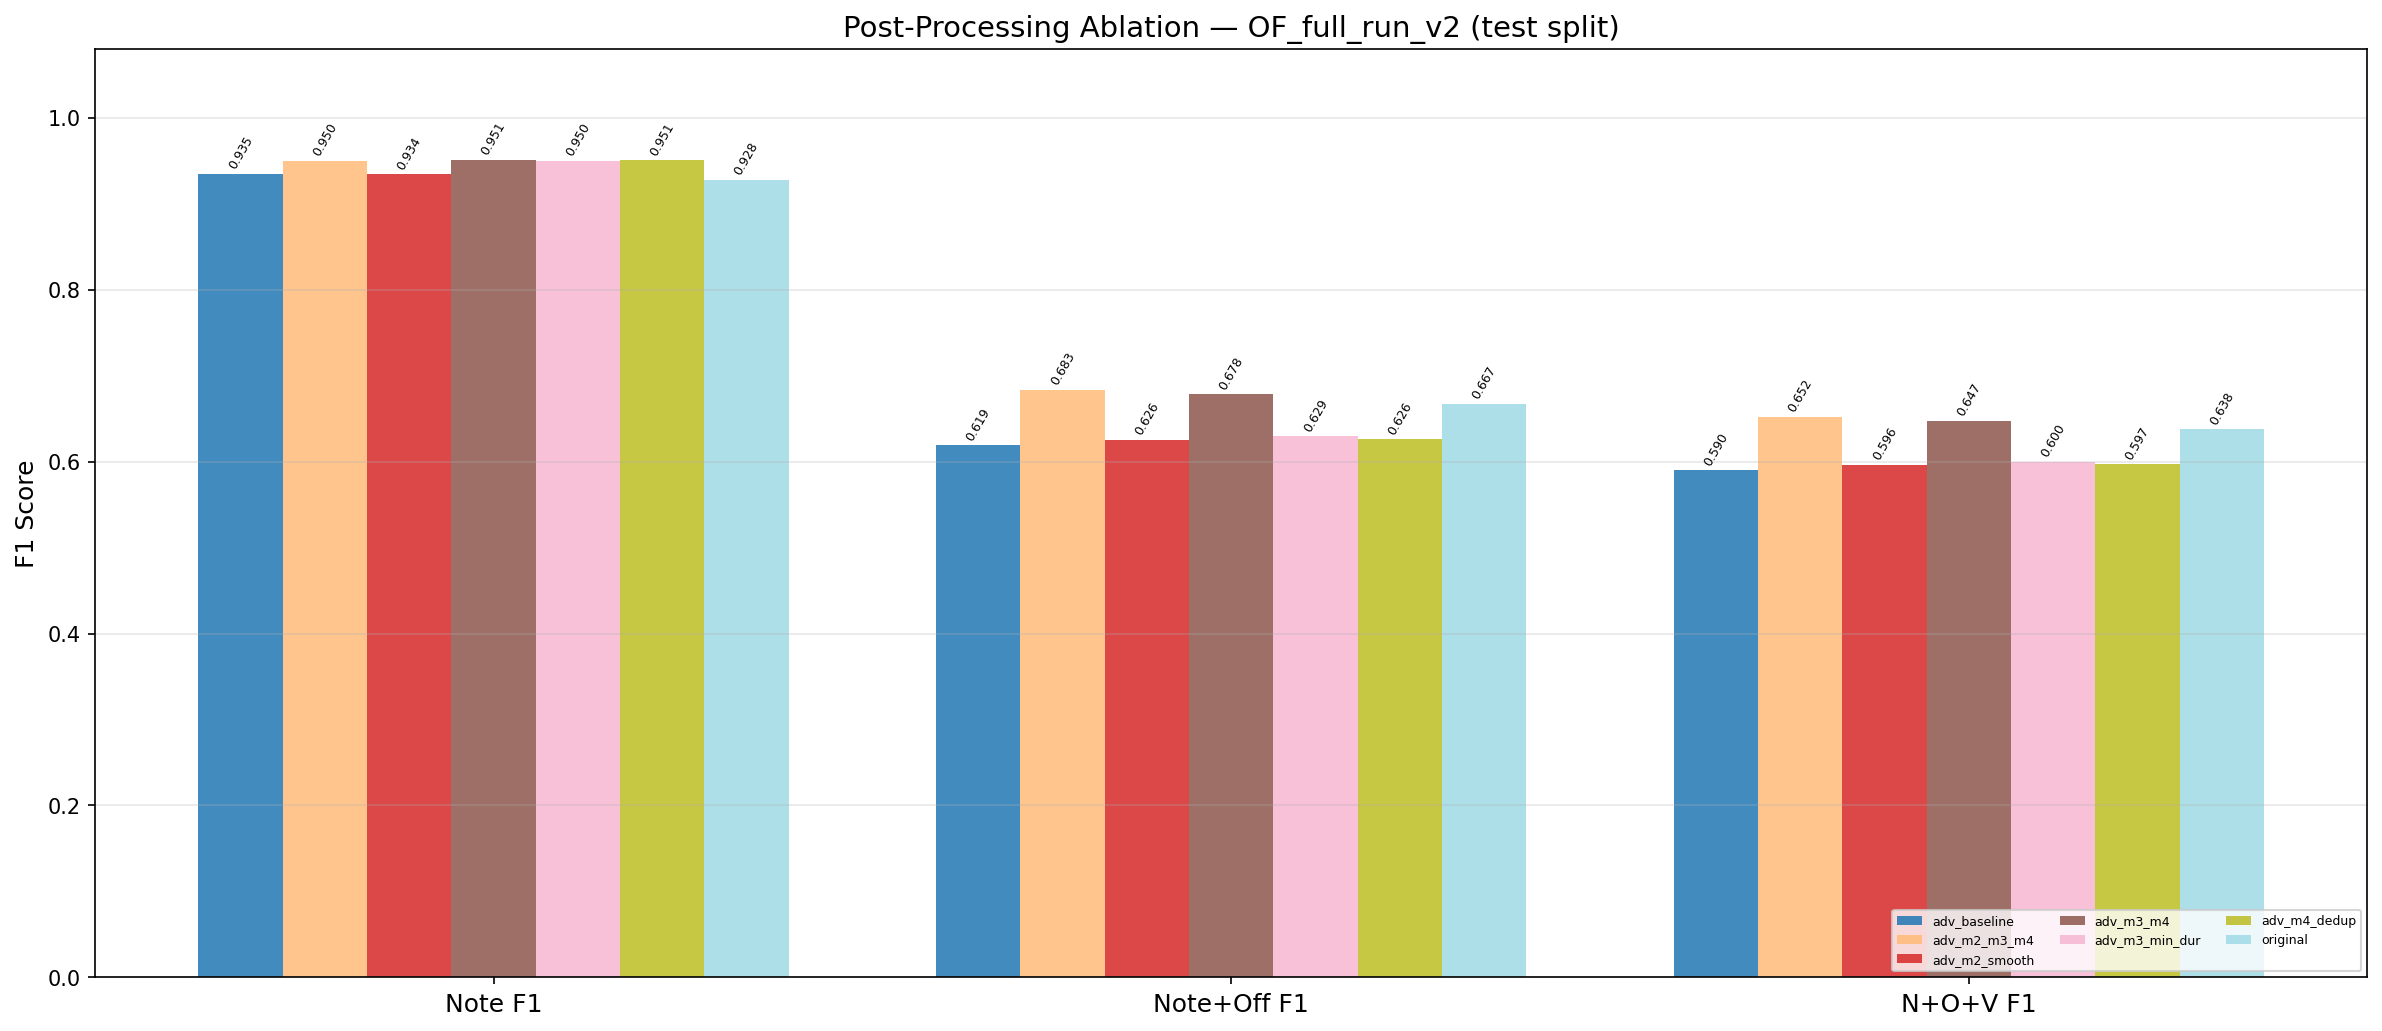

In [44]:
# ── Bar Chart ────────────────────────────────────────────────────────────────
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image

ordered = sorted(ALL_SUMMARIES.keys())
configs = ordered
n_configs = len(configs)

metrics_to_plot = [
    ('adv_note_f1', 'note_f1', 'Note F1'),
    ('adv_note_with_offset_f1', 'note_with_offset_f1', 'Note+Off F1'),
    ('adv_note_with_offset_vel_f1', 'note_with_offset_vel_f1', 'N+O+V F1'),
]

x = np.arange(len(metrics_to_plot))
width = 0.8 / max(n_configs, 1)
colors = plt.cm.tab20(np.linspace(0, 1, max(n_configs, 1)))

fig, ax = plt.subplots(figsize=(16, 7))

for i, cfg in enumerate(configs):
    s = ALL_SUMMARIES[cfg]
    vals = []
    for adv_key, orig_key, _ in metrics_to_plot:
        vals.append(s.get(adv_key, s.get(orig_key, 0)))
    offset = (i - n_configs / 2 + 0.5) * width
    bars = ax.bar(x + offset, vals, width, label=cfg, color=colors[i], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{v:.3f}", ha='center', va='bottom', fontsize=6, rotation=60)

ax.set_xticks(x)
ax.set_xticklabels([label for _, _, label in metrics_to_plot], fontsize=12)
ax.set_ylim(0, 1.08)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title(f'Post-Processing Ablation — OF_full_run_v2 ({SPLIT} split)', fontsize=14)
ax.legend(fontsize=6, loc='lower right', ncol=3)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
save_path = str(run_dir / f'pp_ablation_{SPLIT}.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Chart saved → {save_path}")
plt.close(fig)
Image(save_path)

In [45]:
# ── Find Best Config ────────────────────────────────────────────────────────

best_cfg = None
best_noff = 0

for cfg, s in ALL_SUMMARIES.items():
    noff = s.get('adv_note_with_offset_f1', s.get('note_with_offset_f1', 0))
    if noff > best_noff:
        best_noff = noff
        best_cfg = cfg

print('=' * 60)
print('BEST POST-PROCESSING CONFIGURATION')
print('=' * 60)

if best_cfg:
    s = ALL_SUMMARIES[best_cfg]
    print(f"\n  Config: {best_cfg}")
    print(f"  Note F1:       {s.get('adv_note_f1', s.get('note_f1', 0)):.4f}  (Δ {s.get('adv_note_f1', s.get('note_f1', 0)) - base_note:+.4f})")
    print(f"  Note+Off F1:   {best_noff:.4f}  (Δ {best_noff - base_noff:+.4f})")
    adv_nov = s.get('adv_note_with_offset_vel_f1', s.get('note_with_offset_vel_f1', 0))
    print(f"  N+O+V F1:      {adv_nov:.4f}  (Δ {adv_nov - base_noffv:+.4f})")

    pp = s.get('post_processing', {})
    if pp:
        print(f"\n  Active methods:")
        if pp.get('use_onset_conditioned_offset'): print(f"    ✓ M1: Onset-Conditioned Offset")
        if pp.get('use_frame_smoothing'): print(f"    ✓ M2: Frame Smoothing (kernel={pp.get('frame_smoothing_kernel')})")
        if pp.get('min_note_duration_ms', 16) != 16: print(f"    ✓ M3: Min Duration = {pp.get('min_note_duration_ms')}ms")
        if pp.get('use_duplicate_removal'): print(f"    ✓ M4: Duplicate Removal")
        if pp.get('use_chord_grouping'): print(f"    ✓ M5: Chord Grouping")
        if pp.get('use_adaptive_thresholds'): print(f"    ✓ M6: Adaptive Thresholds")
        if pp.get('use_pedal_extension'): print(f"    ✓ M7: Pedal Extension")

    print(f"\n  → Use this config as input to your Transformer refiner.")

print('=' * 60)

BEST POST-PROCESSING CONFIGURATION

  Config: adv_m2_m3_m4
  Note F1:       0.9502  (Δ +0.0155)
  Note+Off F1:   0.6833  (Δ +0.0641)
  N+O+V F1:      0.6523  (Δ +0.0622)

  Active methods:
    ✓ M2: Frame Smoothing (kernel=3)
    ✓ M3: Min Duration = 55.0ms
    ✓ M4: Duplicate Removal

  → Use this config as input to your Transformer refiner.


In [46]:
# ── Save CSV + LaTeX ─────────────────────────────────────────

rows_csv = []
for cfg in sorted(ALL_SUMMARIES.keys()):
    s = ALL_SUMMARIES[cfg]
    rows_csv.append({
        'Config': cfg,
        'Note F1': round(s.get('adv_note_f1', s.get('note_f1', 0)), 4),
        'Note+Off F1': round(s.get('adv_note_with_offset_f1', s.get('note_with_offset_f1', 0)), 4),
        'N+O+V F1': round(s.get('adv_note_with_offset_vel_f1', s.get('note_with_offset_vel_f1', 0)), 4),
        'Frame F1': round(s.get('frame_f1', 0), 4),
        'Offset MAE (ms)': round(s.get('ea_offset_mae_ms', 0), 1),
        'Onset MAE (ms)': round(s.get('ea_onset_mae_ms', 0), 1),
        'Chord Comp': round(s.get('ea_chord_completeness', 0), 4),
        'Dup Rate': round(s.get('ea_duplicate_note_rate', 0), 4),
        'Eval Time (s)': s.get('eval_time_total_s', 0),
    })

df = pd.DataFrame(rows_csv)

# ── CSV export ────────────────────────────────────────────────
csv_path = str(run_dir / f'pp_ablation_{SPLIT}.csv')
df.to_csv(csv_path, index=False)
print(f"CSV saved → {csv_path}")

# ── LaTeX export ──────────────────────────────────────────────
latex_path = str(run_dir / f'pp_ablation_{SPLIT}.tex')

# Escape underscores in config names for LaTeX safety
df_latex = df.copy()
df_latex['Config'] = df_latex['Config'].str.replace('_', r'\_', regex=False)

latex_str = df_latex.to_latex(
    index=False,
    float_format=lambda x: f'{x:.4f}' if isinstance(x, float) and abs(x) < 100 else f'{x:.1f}',
    caption=(
        f'Post-processing ablation results on the MAESTRO v3.0.0 '
        f'{SPLIT} split (n=137). All configurations evaluated with '
        f'decode thresholds (onset=0.40, frame=0.40, offset=0.50) '
        f'and mir\\_eval tolerances (onset=50ms, offset\\_ratio=0.2, '
        f'velocity=0.1).'
    ),
    label=f'tab:pp_ablation_{SPLIT}',
    column_format='l' + 'r' * (len(df.columns) - 1),
    escape=False,
    position='htbp',
)

with open(latex_path, 'w') as f:
    f.write(latex_str)

print(f"LaTeX saved → {latex_path}")
print()
print(df.to_string(index=False))
print()
print("─" * 60)
print("LaTeX preview:")
print("─" * 60)
print(latex_str)

CSV saved → /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/pp_ablation_test.csv
LaTeX saved → /content/drive/MyDrive/piano_amt/runs/OF_full_run_v2/pp_ablation_test.tex

        Config  Note F1  Note+Off F1  N+O+V F1  Frame F1  Offset MAE (ms)  Onset MAE (ms)  Chord Comp  Dup Rate  Eval Time (s)
  adv_baseline   0.9347       0.6192    0.5901    0.7793            112.9             3.6      0.9133    0.0348          499.9
  adv_m2_m3_m4   0.9502       0.6833    0.6523    0.7922             89.9             4.0      0.9091    0.0000         1427.8
 adv_m2_smooth   0.9343       0.6256    0.5963    0.7720            112.6             3.6      0.9123    0.0348         1357.5
     adv_m3_m4   0.9510       0.6782    0.6473    0.7981             90.3             4.0      0.9111    0.0000          543.1
adv_m3_min_dur   0.9499       0.6292    0.5997    0.7793            110.0             4.1      0.9109    0.0000          496.0
  adv_m4_dedup   0.9507       0.6259    0.5967    0.7793       

In [ ]:
# ── Save CSV  ────────────────────────────────────────────────

rows_csv = []
for cfg in sorted(ALL_SUMMARIES.keys()):
    s = ALL_SUMMARIES[cfg]
    rows_csv.append({
        'Config': cfg,
        'Note F1': round(s.get('adv_note_f1', s.get('note_f1', 0)), 4),
        'Note+Off F1': round(s.get('adv_note_with_offset_f1', s.get('note_with_offset_f1', 0)), 4),
        'N+O+V F1': round(s.get('adv_note_with_offset_vel_f1', s.get('note_with_offset_vel_f1', 0)), 4),
        'Frame F1': round(s.get('frame_f1', 0), 4),
        'Offset MAE (ms)': round(s.get('ea_offset_mae_ms', 0), 1),
        'Onset MAE (ms)': round(s.get('ea_onset_mae_ms', 0), 1),
        'Chord Comp': round(s.get('ea_chord_completeness', 0), 4),
        'Dup Rate': round(s.get('ea_duplicate_note_rate', 0), 4),
        'Eval Time (s)': s.get('eval_time_total_s', 0),
    })

df = pd.DataFrame(rows_csv)
csv_path = str(run_dir / f'pp_ablation_{SPLIT}.csv')
df.to_csv(csv_path, index=False)
print(f"CSV saved → {csv_path}")
print()
print(df.to_string(index=False))